# Good noise pulses overlaid — series 07221203_2025

Follow-up to `dump1_noise_pulses.ipynb`: take the traces that passed the "good noise"
cut there (`good_noise_traces.csv` — 21 traces, `BASELINE_STD_CAP=5`,
`GOOD_RATIO_THRESH=2.45`) and overlay them on one axis, all baseline-subtracted, to see
how consistent they look as a group.

Restricted to a **single channel** for now — channel 0, since it's the best-represented
channel in the passing set. Run with the `darkmatter_cli_env` conda environment.

In [1]:
from nsdf_dark_matter.idx import load_all_data
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

home_directory = Path.home()
series_path = str(home_directory) + '/idx/07221203_2025_F0001'
cdms = load_all_data(series_path)

PRETRIGGER_SAMPLES = 1000
CHANNEL = 0

with open('good_noise_traces.csv') as f:
    good_rows = [r for r in csv.DictReader(f) if int(r['channel']) == CHANNEL]

print(f"channel {CHANNEL}: {len(good_rows)} passing traces")

channel 0: 14 passing traces


## Overlay plot

Each trace is baseline-subtracted (mean of its own first 1000 samples). A couple of
these traces have a single-sample startup transient somewhere in the first few dozen
samples (a known quirk of this raw digitizer data, not a real pulse) — the y-axis is
clipped to the 0.5-99.5 percentile of all plotted samples so that doesn't wash out the
noise texture; any such spike just runs off the top/bottom of the plot.

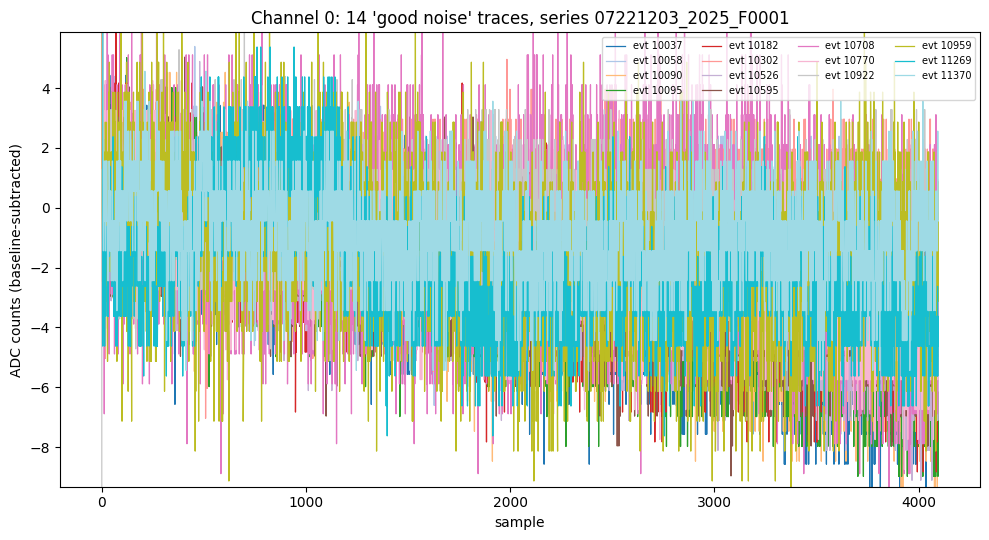

In [2]:
traces = []
for r in good_rows:
    detector_id = f"{r['event']}_{r['group']}_Phonon_4096"
    trace = cdms.get_detector_channels(detector_id)[CHANNEL].astype(np.float64)
    trace -= trace[:PRETRIGGER_SAMPLES].mean()
    traces.append((r['event'], trace))

all_samples = np.concatenate([t for _, t in traces])
ylo, yhi = np.percentile(all_samples, [0.5, 99.5])
pad = 0.15 * (yhi - ylo)

colors = plt.cm.tab20(np.linspace(0, 1, len(traces)))

fig, ax = plt.subplots(figsize=(10, 5.5))
for (event, trace), color in zip(traces, colors):
    ax.plot(trace, linewidth=0.9, color=color, label=f"evt {event}")

ax.set_ylim(ylo - pad, yhi + pad)
ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Channel {CHANNEL}: {len(traces)} 'good noise' traces, series 07221203_2025_F0001")
ax.legend(fontsize=7, ncol=4, loc="upper right")
fig.tight_layout()
plt.show()

## FFT of all traces, compared

Take the real FFT (`np.fft.rfft`) of every one of the traces shown above and overlay
all of their real and imaginary parts on one pair of axes, using the same
per-event colors as the overlay plot.

Notes:
- The true ADC sample rate for this readout isn't established anywhere in the repo or
  run log, so the x-axis here is **normalized frequency** (cycles/sample, 0 to 0.5)
  rather than Hz — trivial to rescale once the real sample rate is known.
- As in the time-domain overlay, the occasional single-sample startup transient leaks
  broadband power into the low-frequency bins; the y-axes are percentile-clipped across
  *all* traces together so the shared spectral shape stays visible.

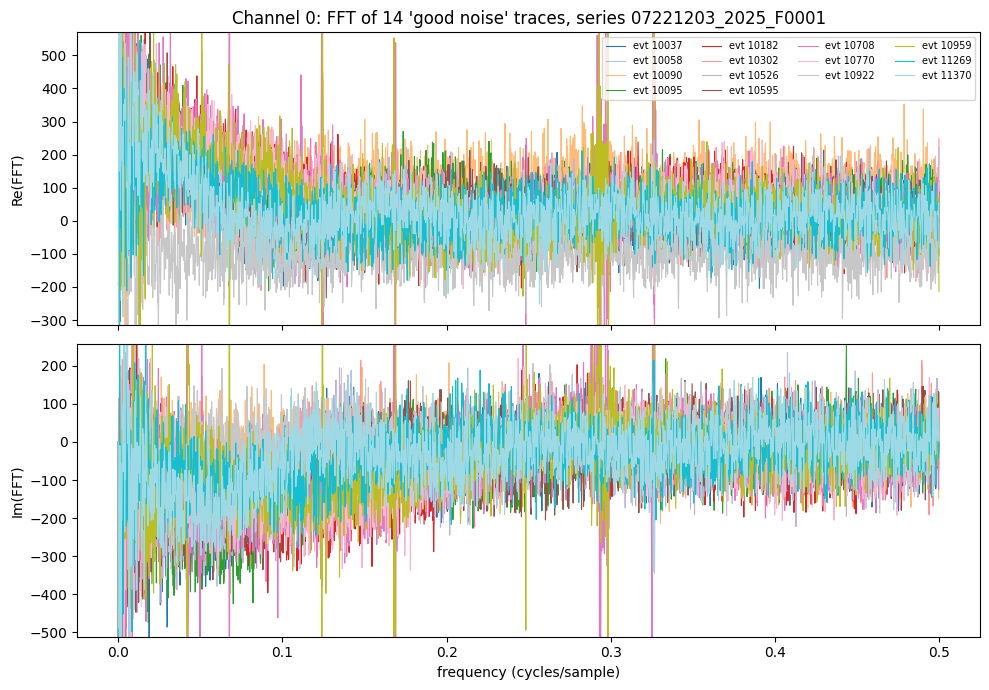

In [3]:
spectra = []
for event, trace in traces:
    spectrum = np.fft.rfft(trace)
    spectra.append((event, spectrum))

freqs = np.fft.rfftfreq(traces[0][1].shape[0], d=1.0)  # cycles/sample; real sample rate unknown

all_re = np.concatenate([s.real for _, s in spectra])
all_im = np.concatenate([s.imag for _, s in spectra])
re_lo, re_hi = np.percentile(all_re, [0.5, 99.5])
im_lo, im_hi = np.percentile(all_im, [0.5, 99.5])
re_pad = 0.15 * (re_hi - re_lo)
im_pad = 0.15 * (im_hi - im_lo)

fig, (ax_re, ax_im) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for (event, spectrum), color in zip(spectra, colors):
    ax_re.plot(freqs, spectrum.real, linewidth=0.8, color=color, label=f"evt {event}")
    ax_im.plot(freqs, spectrum.imag, linewidth=0.8, color=color)

ax_re.set_ylim(re_lo - re_pad, re_hi + re_pad)
ax_re.set_ylabel("Re(FFT)")
ax_re.set_title(f"Channel {CHANNEL}: FFT of {len(spectra)} 'good noise' traces, series 07221203_2025_F0001")
ax_re.legend(fontsize=7, ncol=4, loc="upper right")

ax_im.set_ylim(im_lo - im_pad, im_hi + im_pad)
ax_im.set_ylabel("Im(FFT)")
ax_im.set_xlabel("frequency (cycles/sample)")

fig.tight_layout()
plt.show()

## Next steps

- Repeat for the other channels represented in the passing set (1 and 3 — channel 2
  never passes the cut at this threshold, worth understanding why).
- If these overlay cleanly as a consistent noise band, they're a reasonable candidate
  set for a per-channel noise PSD (per the original notebook's next-steps note).

## Complex square of the FFTs

For each trace, `spectrum * conj(spectrum)` — the (unnormalized) power spectrum —
plotted for all traces on one log-scale axis. The imaginary part of this product is
zero by construction (up to floating-point noise), so only the real part is plotted;
log scale is used instead of the percentile clipping from the plots above since power
spans several orders of magnitude across frequency.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for (event, spectrum), color in zip(spectra, colors):
    power = (spectrum * np.conj(spectrum)).real
    ax.plot(freqs, power, linewidth=0.8, color=color, label=f"evt {event}")

ax.set_yscale("log")
ax.set_xlabel("frequency (cycles/sample)")
ax.set_ylabel(r"$|\mathrm{FFT}|^2$")
ax.set_title(f"Channel {CHANNEL}: complex square of the FFT, {len(spectra)} 'good noise' traces")
ax.legend(fontsize=7, ncol=4, loc="upper right")
fig.tight_layout()
plt.show()